In [122]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib import cm

In [123]:
def func3d(x):
    x1, x2 = x
    f = 0.8
    return np.cos(x1*f) * (25 - x1**2) - np.cos(x2*f) * (25 - x2**2)

In [124]:

def grad3d(x):
    x1, x2 = x
    h = 0.01
    h1 = np.array([h, 0.0])
    h2 = np.array([0.0, h])
    z = func3d(x)
    df_dx = (func3d(x+h1) - z)/h
    df_dy = (func3d(x+h2) - z)/h
    return np.array([df_dx, df_dy])

In [ ]:
def grad_desc(x, step=0.005):
    x = x - step*grad3d(x)
    return x

In [126]:
values = np.array([np.outer(np.linspace(-5.0, 5.0, 100), np.ones(100)), \
    np.outer(np.ones(100), np.linspace(-5.0, 5.0, 100))])
z = func3d(values)

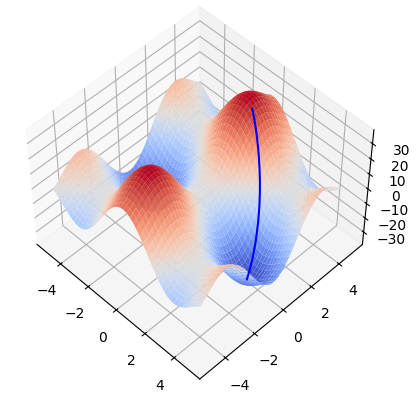

In [128]:
xi = np.array([0.5, 3.0])


xs = []
zs = []

for i in range(10000):
    zi = func3d(xi)
    xs.append(xi)
    zs.append(zi)
    xi = grad_desc(xi)

xs = np.array(xs)
zs = np.array(zs)

ax = plt.axes(projection='3d')
ax.view_init(50, -45)
ax.plot_surface(values[0,:], values[1,:], z, cmap=cm.coolwarm)
ax.plot(xs[:,0], xs[:,1], zs, '-', c='b', zorder=100)
